In [3]:
import os
# Set the environment variable
os.environ['STPSF_PATH'] = os.path.abspath("/npool/nvme/yuchialin/JWST/stpsf_data")
os.environ['WEBBPSF_EXT_PATH'] = "/npool/nvme/yuchialin/JWST/webbpsf_ext_data"
os.environ['PYSYN_CDBS'] = "/npool/nvme/yuchialin/JWST/webbpsf_ext_data/cdbs"
os.environ['CRDS_PATH'] = "/npool/nvme/yuchialin/JWST/crds_cache"
os.environ['CRDS_SERVER_URL'] = "https://jwst-crds.stsci.edu"

# Verify the variable is set
print("STPSF_PATH:", os.environ['STPSF_PATH'])
print("WEBBPSF_EXT_PATH:", os.environ['WEBBPSF_EXT_PATH'])
print("PYSYN_CDBS:", os.environ['PYSYN_CDBS'])
print("CRDS_PATH:", os.environ['CRDS_PATH'])

STPSF_PATH: /npool/nvme/yuchialin/JWST/stpsf_data
WEBBPSF_EXT_PATH: /npool/nvme/yuchialin/JWST/webbpsf_ext_data
PYSYN_CDBS: /npool/nvme/yuchialin/JWST/webbpsf_ext_data/cdbs
CRDS_PATH: /npool/nvme/yuchialin/JWST/crds_cache


In [4]:
# Imports
from IPython.display import display, HTML

def setup_display(width=95, fontsize=16):
    """
    Sets window width and markdown fontsize for Jupyter notebook. Width is % of window.
    """
    display(HTML("<style>.container { width:"+str(width)+"% !important; }</style>"))
    display(HTML("<style>.rendered_html { font-size: "+str(fontsize)+"px; }</style>"))
    return None

def source(fn):
    import inspect
    print(inspect.getsource(fn))
    return None

import numpy as np
import glob
import winnie
from winnie.plot import animate_quick_implot, quick_implot, mpl, plt
from spaceKLIP import database
import webbpsf
import astropy.units as u

plt.style.use('winnie.winnie_mplstyle') # Comment this out or replace it if you prefer a different plot style

setup_display()

In [5]:
# Prep the SpaceRDI object:
#https://simbad.u-strasbg.fr/simbad/sim-basic?Ident=TW+Hya&submit=SIMBAD+search
#approximately 16.63 milliarcseconds (mas)
#Distance (parsecs) = 1000 / 16.63 ≈ 60.14 parsecs
distance = 60.14 # Distance to your target in parsecs

base_dir = 'data_twhya_winnie/'
input_dir = f'{base_dir}padded/'
data_ext = 'calints'
fitsfiles = np.sort(glob.glob(f'{input_dir}*{data_ext}.fits')) # Populate a file list

# Initialize the spaceKLIP database
Database = database.Database(base_dir)
Database.verbose = False
Database.read_jwst_s012_data(datapaths=fitsfiles)

# Create the SpaceRDI object we'll use to carry out RDI
wdb = winnie.SpaceRDI(Database, output_subdir='WinnieRDI', overwrite=True, verbose=True, pad_data='auto')

In [6]:

import webbpsf_ext

# Create synphot spectrum from BOSZ grid (Bohlin et al 2017, Mészáros et al. 2024, https://archive.stsci.edu/hlsp/bosz)
# In this case, normalized a ~M0V star to 2MASS K'-Band of 7.3 mags
# Stellar properties (Teff=3800K, log_g=4.2) are from Sokal et al (2018, ApJ, 853, 120)
bp_k = webbpsf_ext.bp_2mass('k')
sp = webbpsf_ext.stellar_spectrum('M0V', 7.3, 'vegamag', bp_k, Teff=3800, log_g=4.2, metallicity=0.0)

# You can create arbitrary synphot spectrum from arrays like so:
# sp = webbpsf_ext.synphot_ext.ArraySpectrum(wave=np.array([...]), flux=np.array([...]), wave_unit='angstrom', flux_unit='flam')
# wave_unit can be 'angstrom', 'um', 'nm', etc.
# flux_unit can be 'Jy', 'flam' (erg/s/cm^2/Angstrom), 'photlam' (photons/s/cm^2/Angstrom), etc

# Obtain magnitude values in NIRCam filters
bp_list = ['F200W', 'F356W', 'F444W']
for filt in bp_list:
    bp = webbpsf_ext.nircam_filter(filt, pupil='CIRCLYOT', mask='MASK335R', module='A')
    obs = webbpsf_ext.synphot_ext.Observation(sp, bp, binset=bp.waveset)
    print(f"{filt} Flux Density: {obs.effstim('Jy'):.3f} Jy")

sp = webbpsf_ext.synphot_ext.ArraySpectrum(wave=np.array(sp.wave), flux=np.array(sp.flux))
sp.convert('flam')  # Convert to erg/s/cm^2/Angstrom
#wave = sp.wave
#flux = sp.flux
#wdb.prepare_convolution(sp, fov_pixels=201, osamp=2, grid_kwargs=dict(nr=12, ntheta=4), recalc_psf_grid=True)
wdb.prepare_convolution(sp, fov_pixels=201, osamp=2, grid_kwargs=dict(nr=12, ntheta=4))

# Old Spectrum: Spectrum to assume for the convolution PSFs; we're just using an M0V.
#import stpsf
#spec_synphot = stpsf.specFromSpectralType('M0V', catalog='ck04')
#wdb.prepare_convolution(spec_synphot, fov_pixels=201, osamp=2, grid_kwargs=dict(nr=12, ntheta=4))

F200W Flux Density: 0.857 Jy
F356W Flux Density: 0.359 Jy
F444W Flux Density: 0.237 Jy


In [7]:
# The first time loading each concatenation will take ~5-10 minutes for generating the PSF grid. Reloading later, it should be much quicker.
wdb.load_concat(0)

JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R
Science data:   2 exposures of shape (650,650)
Reference data: 27 exposures of shape (650,650)

RDI Settings:
Mode: RDI (Winnie)
Extension for output files: 'rdi_psfsub'
1 optimization zone(s)
1 subtraction zone(s)
Setting up sim to match data_twhya_winnie/padded/jw01179005001_03106_00001_nrcalong_calints.fits

MAST OPD query around UTC: 2024-02-14T09:52:09.894
                        MJD: 60354.411225625

OPD immediately preceding the given datetime:
	URI:	 mast:JWST/product/O2024021301-NRCA3_FP1-1.fits
	Date (MJD):	 60353.2554
	Delta time:	 -1.1559 days

OPD immediately following the given datetime:
	URI:	 mast:JWST/product/O2024021601-NRCA3_FP1-1.fits
	Date (MJD):	 60355.7958
	Delta time:	 1.3846 days
User requested choosing OPD time closest in time to 2024-02-14T09:52:09.894, which is O2024021301-NRCA3_FP1-1.fits, delta time -1.156 days
Importing and format-converting OPD from /npool/nvme/yuchialin/JWST/stpsf_data/MAST_JWST_WS

In [8]:
# Run a HPFRDI reduction with default settings.
wdb.hpfrdi_presets()
rdi_reduc = wdb.run_rdi()

JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R
Science data:   2 exposures of shape (650,650)
Reference data: 27 exposures of shape (650,650)

RDI Settings:
Mode: HPFRDI (Winnie)
'opt_smoothing_fn': <function high_pass_filter_sequence at 0x7eead88de660>
'opt_smoothing_kwargs': {'filtersize': 0.969667093183099}
Extension for output files: 'hpfrdi_psfsub'
1 optimization zone(s)
1 subtraction zone(s)


In [9]:
# Disk modeling functions and imports
from winnie.utils import px_size_to_ang_size, ang_size_to_proj_sep, median_filter_sequence
import vip_hci as vip
from vip_hci.fm import ScatteredLightDisk, Phase_function
from astropy import convolution
from IPython.display import clear_output

def grater_2hg_disk_model(r0, h0, ain, aout, pa, incl, g1, g2, wg1,
                          e=0., omega=0., gamma=2., beta=1., xdo=0, ydo=0,
                          cent=np.array([160.,160.]), distance=10., nx=320, ny=320,
                          pxscale=0.063*u.arcsec/u.pixel, accuracy=None, rmax_accuracy=None,
                          halfNbSlices=25, polar=False, flux_max=None):
    """
    A simple ring-like disk morphology based on Augereau et al. (1999) and assuming a linear combo of two H-G SPFs as the scattering phase function.

    r0: fiducial radius in au
    h0: technically h0/r0 — the ratio of scale height to fiducial radius at the fiducial radius
    ain: radial density power law exponent interior to r0
    aout: radial density power law exponent exterior to r0
    pa: disk position angle in degrees
    incl: disk inclination in degrees
    g1: 1st Henyey-Greenstein asymmetry parameter
    g2: 2nd Henyey-Greenstein asymmetry parameter
    wg1: Weight for the SPF term with asymmetry parameter g1 (value in range 0-1); wg2 is 1-wg1
    e: eccentricity
    omega: argument of pericenter in degrees
    gamma: vertical density exponent (gamma = 2 for gaussian)
    beta: disk radial flaring exponent (beta = 1 for linear)

    cent: the pixel position for the center of the disk (generally the location of the star in the data)
    distance: distance to the target in parsecs
    nx: number of x-axis pixels for the image
    ny: number of y-axis pixels for the image
    pxscale: the pixel scale for the data; either a float (must be arcsec/pixel) or astropy units (any units that can be cast to arcsec/pixel)
    accuracy: the numerical accuracy for the model; pixels with density below this value will be set to zero
    rmax_accuracy: if accuracy is None, the model's accuracy is set such that non-zero values are achieved to this separation (in au)
    halfNbSlices: the number of planar slices to compute above and below the disk midplane
    polar: if True, a simple bell-shaped polarization curve is used to generate a polarized intensity image
    flux_max: if not None, normalize the model image so that this is the maximum value.
    """

    def dont_actually_check_inclination(*args, **kwargs):
        """
        VIP's ScatteredLightDisk will normally decrease disk inclination if too high.
        This will cause issues for optimization, so we'd rather live with the artifacts / etc.
        Instead, we just tell VIP that the incl is good whenever it checks.
        We accept *args and **kwargs so it safely replaces the class method.
        """
        return None

    if accuracy is None:
        if rmax_accuracy is None:
            im_corner_dists = np.hypot(*(np.array([[0, 0], [0, ny-1], [nx-1, 0], [nx-1, ny-1]])-cent).T)
            rmax_accuracy = ang_size_to_proj_sep(px_size_to_ang_size(np.max(im_corner_dists), pxscale), distance).value
        accuracy = (rmax_accuracy/r0)**(aout)

    spf = {'name':'DoubleHG', 'g': [g1, g2], 'weight': wg1, 'polar': polar}
    dens = {'name': '2PowerLaws', 'ain': ain, 'aout': aout, 'a': r0, 'ksi0':h0*r0,
            'e': e, 'gamma': gamma, 'beta': beta, 'accuracy': accuracy}

    vip_disk = ScatteredLightDisk(nx=nx, ny=ny, distance=distance,
                                  itilt=incl, pxInArcsec=(pxscale << u.arcsec/u.pixel).value,
                                  pa=pa-180., omega=omega, xdo=xdo, ydo=ydo,
                                  density_dico=dens, spf_dico=spf, flux_max=flux_max,
                                  xs=cent[0], ys=cent[1])

    vip_disk.dust_density.accuracy = accuracy
    vip_disk.dust_density.dust_distribution_calc.rmax = vip_disk.dust_density.dust_distribution_calc.a*accuracy**(1/vip_disk.dust_density.dust_distribution_calc.aout)
    
    # Override check_inclination bounding to avoid breaking optimization
    vip_disk.check_inclination = dont_actually_check_inclination.__get__(vip_disk, ScatteredLightDisk)
    
    disk = vip_disk.compute_scattered_light(halfNbSlices=halfNbSlices)

    # For disks with material coincident with the stellar position along the line of sight, VIP returns an image with a plus-sign shaped region of zeros at the star's position
    # The below is a quick work-around to correct this. Very likely makes zero difference following PSF-convolution
    if cent[0]%1 == 0:
        jvals = (np.array([-1,0,1])+cent[0]).astype(int)
    else:
        jvals = np.array([np.floor(cent[0]), np.ceil(cent[0])]).astype(int)
        
    if cent[1]%1 == 0:
        ivals = (np.array([-1,0,1])+cent[1]).astype(int)
    else:
        ivals = np.array([np.floor(cent[1]), np.ceil(cent[1])]).astype(int)
        
    for j in jvals:
        disk[int(cent[1]),j] = np.nan
    for i in ivals:
        disk[i,int(cent[0])] = np.nan
        
    disk = convolution.interpolate_replace_nans(disk, np.ones((3,3)))
    return disk

# Single Ring Model Optimization

Fixed Parameters
- ring locations (r0): 52 AU
- scale height (h0): 0.035
- dust density distribution (ain, aout): 5, -5
- scattering phase function parameters (g1, g2, wg1): 0.85, -0.2, 0.75
- disk geometry (incl, pa): 0, 0

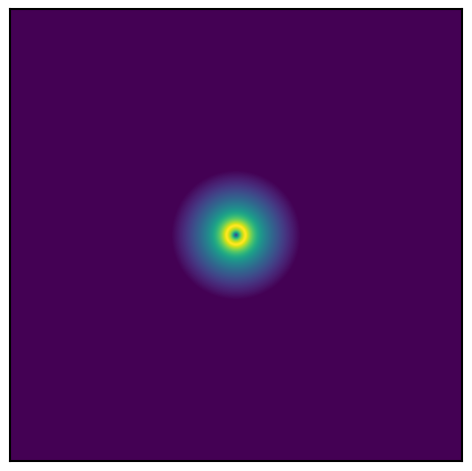

In [10]:
# Disk parameters (see grater_2hg_disk_model docstring)
# These are just some quick guesses to get something resembling what we actually see
r0, h0, ain, aout, pa, incl =  52, 0.035, 5, -5, 0, 0
g1, g2, wg1 = 0.85, -0.2, 0.75
flux_max = 36.991

raw_model = grater_2hg_disk_model(r0, h0, ain, aout, pa, incl, g1, g2, wg1,
                                  cent=wdb.c_star, distance=distance,
                                  nx=wdb.nx, ny=wdb.ny, pxscale=wdb.pxscale,
                                  flux_max=flux_max)

quick_implot(raw_model, norm=mpl.colors.LogNorm, norm_kwargs=dict(clip=True), clim='0.00001*99.99%, 99.99%')


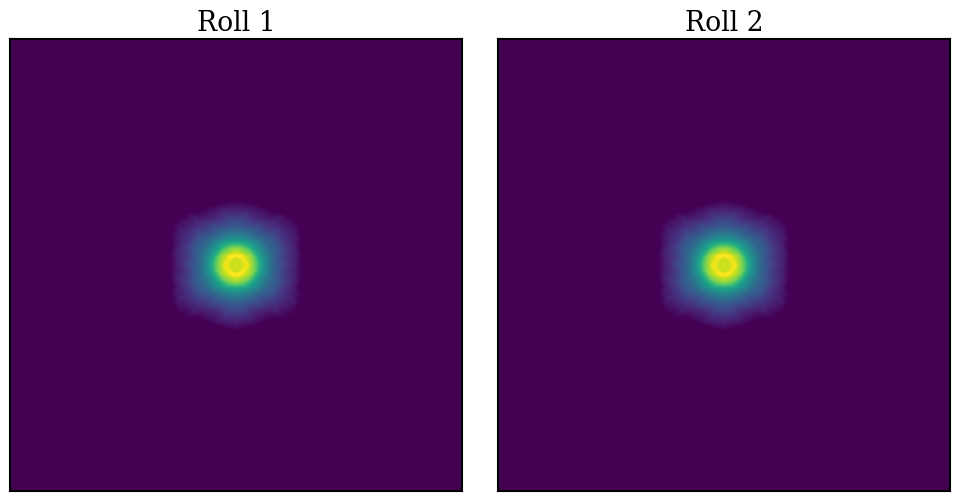

In [15]:
# Resample our raw model (if needed), rotate it to the position angles of the observations, multiply it by the coronagraph transmission map for each roll,
# and then convolve our raw model with the previously generated PSF grid:

model_cube = wdb.convolver.convolve_model(raw_model, wdb.pxscale, wdb.c_star)

fig,axes = quick_implot(model_cube, norm=mpl.colors.LogNorm, norm_kwargs=dict(clip=True), clim='0.001*99.99%, 99.99%', show=False)

for i, ax in enumerate(axes):
    ax.set_title(f'Roll {i+1}')
    
plt.show()

In [16]:
# Set the resulting model_cube as our circumstellar scene (CSS) model in the Winnie SpaceRDI object
# Then, run High Pass Filtered RDI (HPFRDI) with the forward model option enabled to generate a model RDI image for this disk model.
wdb.set_circumstellar_model(model_cube=model_cube)
wdb.hpfrdi_presets()
hpfrdi_singlering = wdb.run_rdi(forward_model=True)

JWST_NIRCAM_NRCALONG_F356W_MASKRND_MASK335R_SUB320A335R
Science data:   2 exposures of shape (650,650)
Reference data: 27 exposures of shape (650,650)

RDI Settings:
Mode: HPFRDI (Winnie)
'opt_smoothing_fn': <function high_pass_filter_sequence at 0x7bf1250d25c0>
'opt_smoothing_kwargs': {'filtersize': 0.969667093183099}
Extension for output files: 'hpfrdi_psfsub'
1 optimization zone(s)
1 subtraction zone(s)


Recommended flux max for the model: 36.991


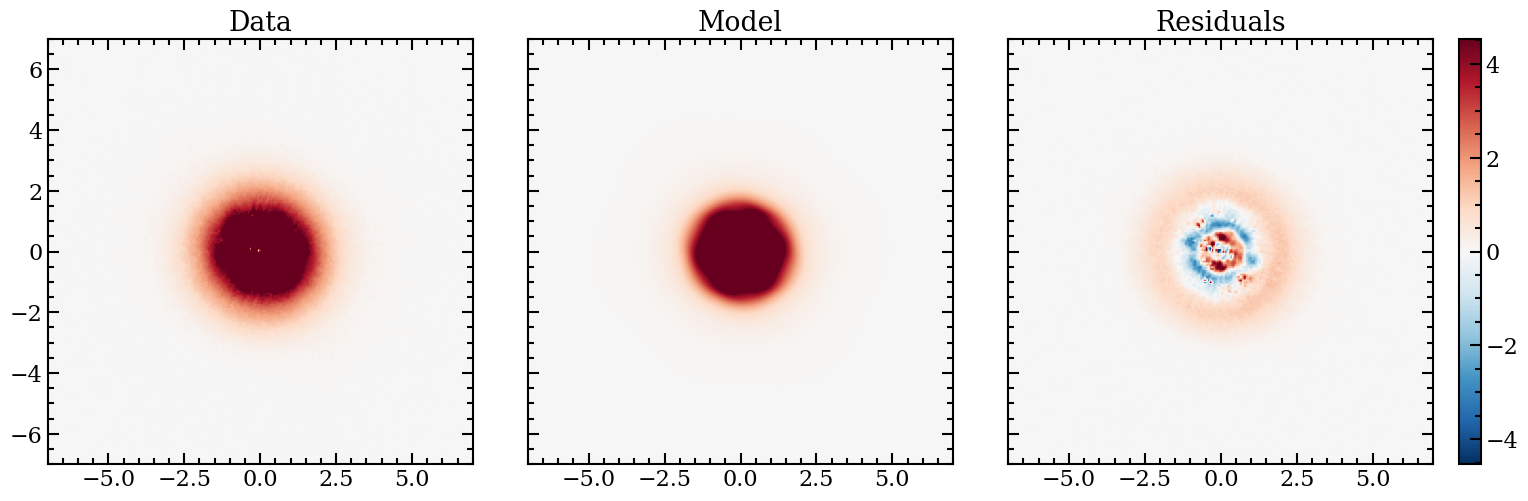

In [17]:
# Plot data, model, and residuals
recom_flux_max = np.nansum(rdi_reduc.im*hpfrdi_singlering.im) / np.nansum(hpfrdi_singlering.im**2)*flux_max
print(f"Recommended flux max for the model: {recom_flux_max:.3f}")
fig,axes,cbar = quick_implot([rdi_reduc.im, hpfrdi_singlering.im, rdi_reduc.im-hpfrdi_singlering.im], cmap='RdBu_r', clim_perc=99, show=False, cbar=True, cbar_kwargs=dict(pad=0.015), panelsize=(6,5), extent=rdi_reduc.extent, lims=[-7,7], show_ticks=True)

labels = ['Data', 'Model', 'Residuals']
for i,ax in enumerate(axes):
    ax.set_title(labels[i])

# Two Ring Model Optimization

Fixed Parameters
- scale height (h0): 0.035
- dust density distribution (ain, aout): 5, -5
- scattering phase function parameters (g1, g2, wg1): 0.85, -0.2, 0.75

In [17]:
# Disk parameters (see grater_2hg_disk_model docstring)
# These are just some quick guesses to get something resembling what we actually see
r0, h0, ain, aout, pa, incl =  52, 0.035, 5, -5, 0, 0
g1, g2, wg1 = 0.85, -0.2, 0.75

[eval 2] new best 1074 | r01=45.29, r02=109.42, flux1=164.96, flux2=2.17
[eval 3] new best 316.4 | r01=51.18, r02=100.25, flux1=20.88, flux2=2.39
[eval 11] new best 292.1 | r01=48.02, r02=100.90, flux1=20.88, flux2=3.04
[iter heartbeat] evals=16, current best=292.1, convergence=0.0144
[eval 20] cost 409.8, best 292.1
[eval 24] new best 221.3 | r01=56.38, r02=105.68, flux1=23.46, flux2=3.52
[iter heartbeat] evals=24, current best=221.3, convergence=0.0126
[eval 26] new best 185.6 | r01=56.38, r02=105.68, flux1=23.46, flux2=2.25
[eval 32] new best 180.8 | r01=53.79, r02=104.21, flux1=20.88, flux2=3.04
[iter heartbeat] evals=32, current best=180.8, convergence=0.0119
[eval 40] cost 341.7, best 180.8
[eval 40] cost 196.9, best 180.8
[iter heartbeat] evals=40, current best=180.8, convergence=0.0161
[eval 46] new best 171.1 | r01=49.72, r02=105.61, flux1=27.07, flux2=3.10
[iter heartbeat] evals=48, current best=171.1, convergence=0.0199
[eval 50] new best 164.8 | r01=45.29, r02=109.42, flux1

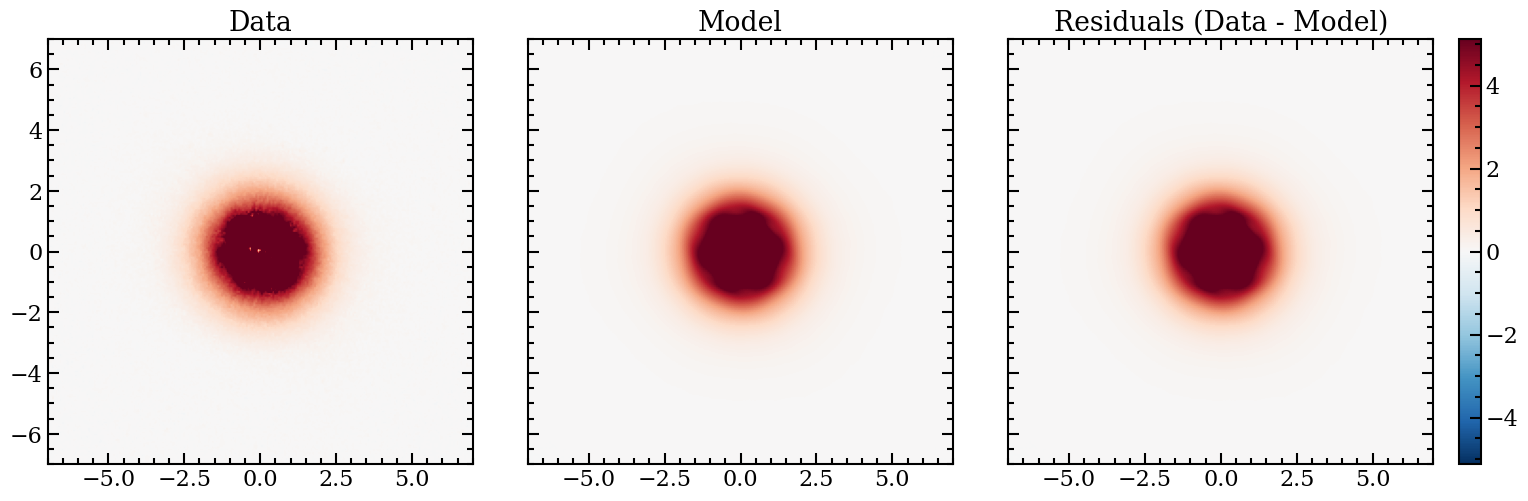

In [ ]:
# Update ring_ranges_au to bracket the three brightness peaks seen in the radial profile.
from scipy.optimize import differential_evolution
from multiprocessing.pool import ThreadPool

# User-set ring ranges in AU (low, high) for three rings
ring_ranges_au = [
    (45, 60),   # Ring 1 range
    (100, 115), # Ring 2 range
]

# Fixed parameters (assuming they are defined in a previous cell like pa and incl)
pa_fixed = 0
incl_fixed = 0
h0_fixed = h0
ain_fixed = ain
aout_fixed = aout
g1_fixed = g1
g2_fixed = g2
wg1_fixed = wg1

n_workers = 2  # threads; shared memory keeps logging consistent

# Bounds: r01, r02, r03, flux1, flux3
bounds = [
    (ring_ranges_au[0][0], ring_ranges_au[0][1]),  # r01
    (ring_ranges_au[1][0], ring_ranges_au[1][1]),  # r02
    (10.0, 250.0),   # flux_max ring1
    (2.0, 4.0),   # flux_max ring2
]

# Precompute radius map in AU
ny, nx = wdb.ny, wdb.nx
j, i = np.meshgrid(np.arange(nx), np.arange(ny))
cent = wdb.c_star
r_pix = np.hypot(i - cent[1], j - cent[0])
r_au = ang_size_to_proj_sep(px_size_to_ang_size(r_pix, wdb.pxscale), distance).value

ring_masks = []
for lo, hi in ring_ranges_au:
    mask = (r_au >= lo) & (r_au <= hi)
    ring_masks.append(mask)

# Eval mask: covers from the inner edge of ring 1 to the outer edge of ring 3
# This ignores the central star residuals, but importantly PENALIZES flux in the gaps between rings.
eval_mask = (r_au >= 5) & (r_au <= 300)

progress_state = {"eval": 0, "best": np.inf}

def build_ring_raw(r0_val, flux_val):
    return grater_2hg_disk_model(
        r0_val,
        h0_fixed,
        ain_fixed,
        aout_fixed,
        pa_fixed,
        incl_fixed,
        g1_fixed,
        g2_fixed,
        wg1_fixed,
        cent=wdb.c_star,
        distance=distance,
        nx=wdb.nx,
        ny=wdb.ny,
        pxscale=wdb.pxscale,
        flux_max=flux_val,
    )

def forward_model_from_raw(raw):
    model_cube = wdb.convolver.convolve_model(raw, wdb.pxscale, wdb.c_star)
    wdb.set_circumstellar_model(model_cube=model_cube)
    return wdb.run_rdi(forward_model=True).im

def objective(theta):
    (
        r01,
        r02,
        flux1_val,
        flux2_val,
    ) = theta
    progress_state["eval"] += 1

    try:
        # Keep geometric ordering stable
        radii_sorted = np.sort([r01, r02])
        r01s, r02s = radii_sorted

        # Ring 1 and 2 are explicitly parameterized by flux_max
        raw1 = build_ring_raw(r01s, flux1_val)
        raw2 = build_ring_raw(r02s, flux2_val)
        fm = forward_model_from_raw(raw1+raw2)

        # Calculat cost
        abs_diff = np.abs(rdi_reduc.im - fm)
        y_idx, x_idx = np.indices(rdi_reduc.im.shape)
        r_pix_sq = (x_idx - wdb.c_star[0])**2 + (y_idx - wdb.c_star[1])**2
        weighted_abs_diff = r_pix_sq * abs_diff
        cost = np.nanmean(weighted_abs_diff[eval_mask])
    except Exception as exc:  # Return a large penalty on failures
        print(f"[eval {progress_state['eval']}] evaluation failed: {exc}")
        return np.inf

    if cost < progress_state["best"]:
        progress_state["best"] = cost
        print(
            f"[eval {progress_state['eval']}] new best {cost:.4g} | "
            f"r01={r01s:.2f}, r02={r02s:.2f}, flux1={flux1_val:.2f}, flux2={flux2_val:.2f}"
        )
    elif progress_state["eval"] % 20 == 0:
        print(
            f"[eval {progress_state['eval']}] cost {cost:.4g}, best {progress_state['best']:.4g}"
        )

    return cost


def progress_callback(xk, convergence):
    print(
        f"[iter heartbeat] evals={progress_state['eval']}, current best={progress_state['best']:.4g}, convergence={convergence:.3g}"
    )
    return False

pool = ThreadPool(n_workers)
try:
    result = differential_evolution(
        objective,
        bounds,
        maxiter=100,
        popsize=n_workers,
        recombination=0.3,
        seed=66,
        polish=False,
        workers=pool.map,  # threads share state with main process
        updating="deferred",
        callback=progress_callback,
    )
finally:
    pool.close()
    pool.join()

(
    best_r01,
    best_r02,
    best_flux1,
    best_flux2,
) = result.x
best_r01, best_r02 = np.sort([best_r01, best_r02])
print("Optimization complete")
print(
    f"r01={best_r01:.2f}, r02={best_r02:.2f}, flux1={best_flux1:.2f}, flux2={best_flux2:.2f}"
)

# Build best-fit ring models and solve ring2 scaling from residual(data - ring1 - ring3)
best_raw1 = build_ring_raw(best_r01, best_flux1)
best_raw2 = build_ring_raw(best_r02, best_flux2)
best_fm = forward_model_from_raw(best_raw1+best_raw2)

best_residual = rdi_reduc.im - best_fm
mask2 = ring_masks[1]

print(f"Best ring scalings: flux1={best_flux1:.3f}, flux2={best_flux2:.3f}")

fig, axes, cbar = quick_implot(
    [rdi_reduc.im, best_fm, best_residual],
    cmap="RdBu_r",
    clim_perc=99,
    show=False,
    cbar=True,
    cbar_kwargs=dict(pad=0.015),
    panelsize=(6, 5),
    extent=rdi_reduc.extent,
    lims=[-7, 7],
    show_ticks=True,
)
for ax, title in zip(axes, ["Data", "Model", "Residuals (Data - Model)"]):
    ax.set_title(title)
plt.show()

# Three Ring Model Optimization

Fixed Parameters
- scale height (h0): 0.035
- dust density distribution (ain, aout): 5, -5
- scattering phase function parameters (g1, g2, wg1): 0.85, -0.2, 0.75

### Optimize three-ring disk parameters with ring-2 residual scaling (PA & incl fixed to 0)

In [10]:
# Disk parameters (see grater_2hg_disk_model docstring)
# These are just some quick guesses to get something resembling what we actually see
r0, h0, ain, aout, pa, incl =  52, 0.035, 5, -5, 0, 0
g1, g2, wg1 = 0.85, -0.2, 0.75

[eval 2] new best 196.4 | r01=26.02, r02=51.77, r03=100.54, flux1=210.77, flux3=3.02, flux2=14.61
[eval 3] new best 173 | r01=20.15, r02=48.51, r03=107.64, flux1=147.59, flux3=3.44, flux2=30.22
[eval 4] new best 155.8 | r01=21.25, r02=47.83, r03=102.34, flux1=196.08, flux3=3.79, flux2=27.96
[eval 20] cost 189.6, best 155.8
[iter heartbeat] evals=20, current best=155.8, convergence=0.0495
[eval 22] new best 155.8 | r01=20.15, r02=48.36, r03=103.91, flux1=144.58, flux3=3.44, flux2=30.33
[iter heartbeat] evals=30, current best=155.8, convergence=0.0478
[eval 36] new best 155.3 | r01=26.66, r02=48.95, r03=104.36, flux1=137.51, flux3=3.54, flux2=20.60
[eval 40] cost 166.3, best 155.3
[iter heartbeat] evals=40, current best=155.3, convergence=0.323
[eval 44] new best 155.2 | r01=28.57, r02=46.76, r03=102.81, flux1=83.42, flux3=3.85, flux2=24.74
[iter heartbeat] evals=50, current best=155.2, convergence=0.346
[eval 53] new best 154.8 | r01=26.98, r02=45.05, r03=102.81, flux1=83.42, flux3=3.83

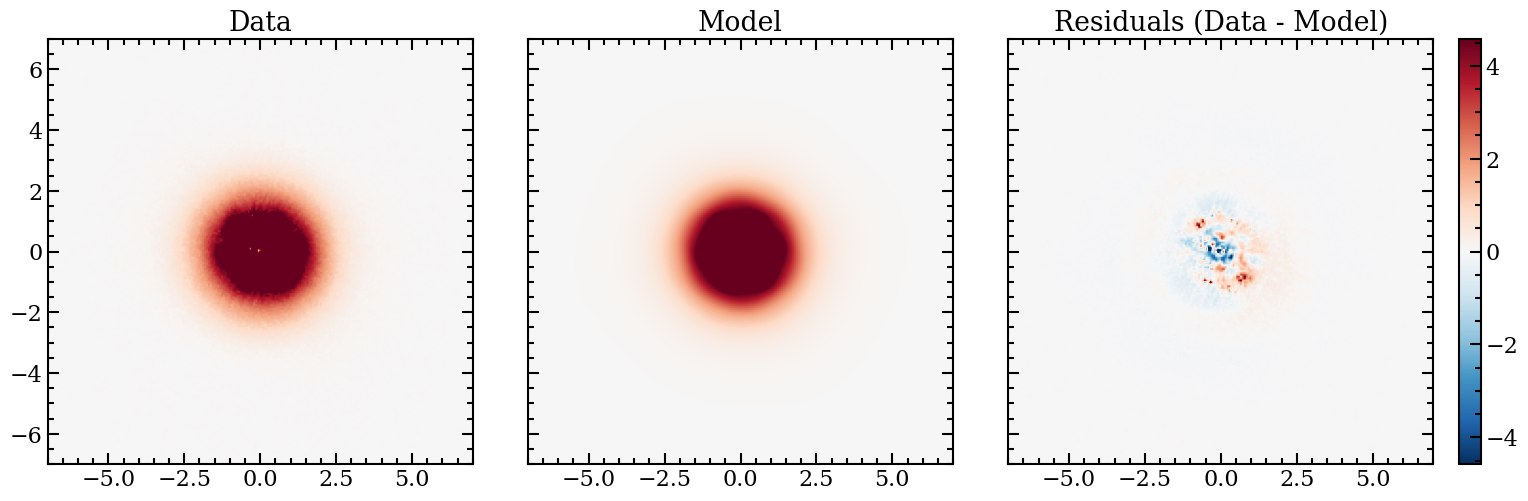

In [ ]:
# best 154.2 | r01=21.61, r02=47.98, r03=104.57, flux1=203.28, flux3=3.44, flux2=27.38
# Update ring_ranges_au to bracket the three brightness peaks seen in the radial profile.
from scipy.optimize import differential_evolution
from multiprocessing.pool import ThreadPool

# User-set ring ranges in AU (low, high) for three rings
ring_ranges_au = [
    (20, 30),   # Ring 1 range
    (45, 55),   # Ring 2 range
    (100, 115), # Ring 3 range
]

# Fixed parameters (assuming they are defined in a previous cell like pa and incl)
pa_fixed = 0
incl_fixed = 0
h0_fixed = h0
ain_fixed = ain
aout_fixed = aout
g1_fixed = g1
g2_fixed = g2
wg1_fixed = wg1

n_workers = 2  # threads; shared memory keeps logging consistent

# Bounds: r01, r02, r03, flux1, flux3
bounds = [
    (ring_ranges_au[0][0], ring_ranges_au[0][1]),  # r01
    (ring_ranges_au[1][0], ring_ranges_au[1][1]),  # r02
    (ring_ranges_au[2][0], ring_ranges_au[2][1]),  # r03
    (50.0, 250.0),   # flux_max ring1
    (2.0, 4.0),   # flux_max ring3
]

# Precompute radius map in AU
ny, nx = wdb.ny, wdb.nx
j, i = np.meshgrid(np.arange(nx), np.arange(ny))
cent = wdb.c_star
r_pix = np.hypot(i - cent[1], j - cent[0])
r_au = ang_size_to_proj_sep(px_size_to_ang_size(r_pix, wdb.pxscale), distance).value

ring_masks = []
for lo, hi in ring_ranges_au:
    mask = (r_au >= lo) & (r_au <= hi)
    ring_masks.append(mask)

# Eval mask: covers from the inner edge of ring 1 to the outer edge of ring 3
# This ignores the central star residuals, but importantly PENALIZES flux in the gaps between rings.
eval_mask = (r_au >= 5) & (r_au <= 300)

progress_state = {"eval": 0, "best": np.inf}

def build_ring_raw(r0_val, flux_val):
    return grater_2hg_disk_model(
        r0_val,
        h0_fixed,
        ain_fixed,
        aout_fixed,
        pa_fixed,
        incl_fixed,
        g1_fixed,
        g2_fixed,
        wg1_fixed,
        cent=wdb.c_star,
        distance=distance,
        nx=wdb.nx,
        ny=wdb.ny,
        pxscale=wdb.pxscale,
        flux_max=flux_val,
    )

def forward_model_from_raw(raw):
    model_cube = wdb.convolver.convolve_model(raw, wdb.pxscale, wdb.c_star)
    wdb.set_circumstellar_model(model_cube=model_cube)
    return wdb.run_rdi(forward_model=True).im

def objective(theta):
    (
        r01,
        r02,
        r03,
        flux1_val,
        flux3_val,
    ) = theta
    progress_state["eval"] += 1

    try:
        # Keep geometric ordering stable
        radii_sorted = np.sort([r01, r02, r03])
        r01s, r02s, r03s = radii_sorted

        # Ring 1 and 3 are explicitly parameterized by flux_max
        raw1 = build_ring_raw(r01s, flux1_val)
        raw3 = build_ring_raw(r03s, flux3_val)

        # Ring 2 template uses unit flux and is solved from residual(data - ring1 - ring3)
        raw2_template = build_ring_raw(r02s, 1.0)

        fm1 = forward_model_from_raw(raw1)
        fm3 = forward_model_from_raw(raw3)
        fm2_template = forward_model_from_raw(raw2_template)

        # Use the specific ring 2 mask just to calculate the scaling magnitude alpha2
        residual13 = rdi_reduc.im - fm1 - fm3
        mask2 = ring_masks[1]
        num2 = np.nansum(residual13[mask2] * fm2_template[mask2])
        den2 = np.nansum(fm2_template[mask2] ** 2) + 1e-12
        alpha2 = max(num2 / den2, 0.0)

        scaled_model = fm1 + alpha2 * fm2_template + fm3
        abs_diff = np.abs(rdi_reduc.im - scaled_model)
        y_idx, x_idx = np.indices(rdi_reduc.im.shape)
        r_pix_sq = (x_idx - wdb.c_star[0])**2 + (y_idx - wdb.c_star[1])**2
        weighted_abs_diff = r_pix_sq * abs_diff
        cost = np.nanmean(weighted_abs_diff[eval_mask])
    except Exception as exc:  # Return a large penalty on failures
        print(f"[eval {progress_state['eval']}] evaluation failed: {exc}")
        return np.inf

    if cost < progress_state["best"]:
        progress_state["best"] = cost
        print(
            f"[eval {progress_state['eval']}] new best {cost:.4g} | "
            f"r01={r01s:.2f}, r02={r02s:.2f}, r03={r03s:.2f}, flux1={flux1_val:.2f}, flux3={flux3_val:.2f}, flux2={alpha2:.2f}"
        )
    elif progress_state["eval"] % 20 == 0:
        print(
            f"[eval {progress_state['eval']}] cost {cost:.4g}, best {progress_state['best']:.4g}"
        )

    return cost


def progress_callback(xk, convergence):
    print(
        f"[iter heartbeat] evals={progress_state['eval']}, current best={progress_state['best']:.4g}, convergence={convergence:.3g}"
    )
    return False

pool = ThreadPool(n_workers)
try:
    result = differential_evolution(
        objective,
        bounds,
        maxiter=100,
        popsize=n_workers,
        recombination=0.3,
        seed=66,
        polish=False,
        workers=pool.map,  # threads share state with main process
        updating="deferred",
        callback=progress_callback,
    )
finally:
    pool.close()
    pool.join()

(
    best_r01,
    best_r02,
    best_r03,
    best_flux1,
    best_flux3,
) = result.x
best_r01, best_r02, best_r03 = np.sort([best_r01, best_r02, best_r03])
print("Optimization complete")
print(
    f"r01={best_r01:.2f}, r02={best_r02:.2f}, r03={best_r03:.2f}, flux1={best_flux1:.2f}, flux3={best_flux3:.2f}"
)

# Build best-fit ring models and solve ring2 scaling from residual(data - ring1 - ring3)
best_raw1 = build_ring_raw(best_r01, best_flux1)
best_raw3 = build_ring_raw(best_r03, best_flux3)
best_raw2_template = build_ring_raw(best_r02, 1.0)

best_fm1 = forward_model_from_raw(best_raw1)
best_fm3 = forward_model_from_raw(best_raw3)
best_fm2_template = forward_model_from_raw(best_raw2_template)

best_residual13 = rdi_reduc.im - best_fm1 - best_fm3
mask2 = ring_masks[1]
num2 = np.nansum(best_residual13[mask2] * best_fm2_template[mask2])
den2 = np.nansum(best_fm2_template[mask2] ** 2) + 1e-12
best_alpha2 = max(num2 / den2, 0.0)

scaled_best = best_fm1 + best_alpha2 * best_fm2_template + best_fm3
print(f"Best ring scalings: flux1={best_flux1:.3f}, flux2={best_alpha2:.3f}, flux3={best_flux3:.3f}")

fig, axes, cbar = quick_implot(
    [rdi_reduc.im, scaled_best, rdi_reduc.im - scaled_best],
    cmap="RdBu_r",
    clim_perc=99,
    show=False,
    cbar=True,
    cbar_kwargs=dict(pad=0.015),
    panelsize=(6, 5),
    extent=rdi_reduc.extent,
    lims=[-7, 7],
    show_ticks=True,
)
for ax, title in zip(axes, ["Data", "Model", "Residuals (Data - Model)"]):
    ax.set_title(title)
plt.show()